---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">GenAI & Advanced Nets: O Mecanismo de Atenção </h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
</div>

---

In [1]:
# Obs: se você não estiver utilizando um ambiente virtual, instale as bibliotecas conforme se apresenta abaixo
%pip install -q -r requirements.txt

# pip é o gerenciador de pacotes do Python. Pense nele como o instalador oficial de libs Python.
# no notebook, usar %pip ... é ideal porque instala no mesmo ambiente do kernel em uso.

# -q: quiet
# -r: requirement file, indica ao pip para instalar os pacotes listados no arquivo requirements.txt


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

<div align="center">

## <span style="color:#1E90FF;">Arquitetura de Transformadores</span>

</div>

A arquitetura de transformadores foi apresentada à comunidade em 2017 pelo papper "*Attention is All You Need*" como podemos verificar na Figura 1.

<div style="text-align: center;">
<p><em>Figura 1: “Attention Is All You Need” (2017).</em></p>
  <img src="imgs/img01.png" alt="Arquitetura de Transformadores" width="500"/>
</div>

Dentro deste artigo, os autores apresentaram um conceito quee viria a mudar todo o cenário de inteligência artifial como se conhecia antes, o mecanismo de atenção. A Figura 2 apresenta a arquiteture de transformadores proposta pelos autores.

<div style="text-align: center;">
<p><em>Figura 2: Arquitetura de Transformadores proposta em “Attention Is All You Need” (2017).</em></p>
  <img src="imgs/img02.png" alt="Arquitetura de Transformadores" width="400"/>
</div>

O ponto central dessa arquitetura é o **mecanismo de atenção**. Na **Figura 2**, ele aparece como *Multi-Head Attention*. Embora a arquitetura original utilize várias cabeças de atenção, neste projeto inicial implementaremos apenas **uma** cabeça de atenção, equivalente ao mecanismo de *Single-Head Attention*.

Na **Figura 2**, também observamos conceitos já consolidados, como **Softmax** e **Feed Forward**, amplamente utilizados em redes neurais há décadas. Em geral, a arquitetura combina esses elementos conhecidos com a inovação do mecanismo de atenção, alcançando resultados expressivos em diversas tarefas de **Processamento de Linguagem Natural (PLN)**.

O ponto de entrada da arquitetura de transformadores são os *inputs*, que em seguida são convertidos em *input embeddings*. Esta etapa é fundamental, pois as fases seguintes exigem representações numéricas. Os *embeddings* cumprem esse papel ao transformar tokens em vetores densos capazes de representar informações semânticas. Esses vetores são posteriormente combinados com informações posicionais (*positional encoding*), permitindo que o modelo capture a ordem dos tokens na sequência.

Ao final do processamento, a representação resultante é projetada novamente para o espaço do vocabulário por meio de uma transformação linear. Com a aplicação da função **Softmax**, o modelo gera uma distribuição de probabilidades sobre todos os tokens possíveis e seleciona o próximo token mais provável. Por esse motivo, na formulação clássica de modelos de linguagem, o Transformer pode ser interpretado como um modelo que realiza **classificação sobre o vocabulário** a cada passo da geração, estimando a probabilidade do próximo token da sequência.

---

<div align="center">

## <span style="color:#1E90FF;">Anatomia da Arquitetura Transformer com PyTorch</span>

</div>

In [2]:
# imports
import warnings
import torch
from torch import nn

# o nn é o módulo do Pytorch para criar redes neurais
# podemos utilizar:
# nn.Linear -> camada totalmente conectada
# nn.Embedding -> cadama de embeddings
# nn.LayerNorm -> cadama de normalização
# nn.ReLU ou nn.GELU -> funções de ativaçao 
# dentre outras demais...

warnings.filterwarnings("ignore")

In [3]:
# classe Transformer implementada com torch
class Transformer(nn.Module):
    # metodo construtor
    # aqui vamos inicializar atributos da classe
    def __init__(self, vocab_size, embedding_dim, n_heads, n_layers, dropout):
        # vamos inicializar tambem o construtor da classe mãe (nn.Modulo)
        super().__init__()

        # vocab_size: tamanho do vocabulario (quantidade total de tokens unicos)
        # embedding_dim: dimensao dos vetores de embedding de cada token
        # n_heads: numero de cabecas de atencao no mecanismo Multi-Head Attention
        # n_layers: quantidade de blocos/camadas Transformer empilhados
        # dropout: taxa de desligamento aleatorio de neuronios para regularizacao (ex.: 0.1)

        # inicializando os atributos
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.n_heads = n_heads
        self.n_layers = n_layers
        self.dropout = dropout

        # definindo a camada de embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # definindo blocos de auto-atenção (n_layers)
        self.attention_layers = nn.ModuleList([
            nn.MultiheadAttention(embedding_dim, n_heads, dropout=dropout, batch_first=True)
            for _ in range(n_layers)
        ])

        # definindo a rede neural feed-forward
        self.feed_forward = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim),
            nn.ReLU(),
            nn.Linear(embedding_dim, embedding_dim)
        )

        # definindo a camada de saída
        self.out = nn.Linear(embedding_dim, vocab_size)

    # método forward
    def forward(self, X):
        # 01. Aplicar a camada de embedding à sequencia de entrada
        x = self.embedding(X)  # (batch, seq, emb)

        # 02. Aplica blocos de multi-head self-attention
        for attention in self.attention_layers:
            attn_out, _ = attention(x, x, x)
            x = x + attn_out  # conexão residual simples

        # 03. Aplica o método feed-forward
        x = self.feed_forward(x)

        # 04. Aplica a camada final
        x = self.out(x)

        return x

---

<div>

## <span style="color:#1E90FF;">Criação do Dataset Sintético</span>

</div>

Após definir a classe `Transformer`, vamos criar um dataset simples para treino de predição de próximo token.

In [4]:
from torch.utils.data import Dataset, DataLoader

class ToyDataset(Dataset):
    def __init__(self, token_ids, seq_len):
        self.x = []
        self.y = []
        for i in range(len(token_ids) - seq_len):
            seq = token_ids[i:i+seq_len+1]
            self.x.append(seq[:-1])  # entrada
            self.y.append(seq[1:])   # alvo deslocado

        self.x = torch.tensor(self.x, dtype=torch.long)
        self.y = torch.tensor(self.y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# criando dados sintéticos
vocab_size = 1000
seq_len = 16
token_ids = torch.randint(0, vocab_size, (5000,)).tolist()

# dataset e dataloader
dataset = ToyDataset(token_ids, seq_len)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

print("Dataset criado com sucesso!")
print(f"Quantidade de amostras: {len(dataset)}")

Dataset criado com sucesso!
Quantidade de amostras: 4984


In [5]:
# apresentando amostras do dataset
print(f"Quantidade de amostras no dataset: {len(dataset)}")

for i in range(3):
    x_ex, y_ex = dataset[i]
    print(f"\nAmostra {i}")
    print("X (entrada):", x_ex.tolist())
    print("y (alvo)   :", y_ex.tolist())

X_batch, y_batch = next(iter(loader))
print("\nFormato de um batch:")
print("X_batch:", X_batch.shape)  # (batch_size, seq_len)
print("y_batch:", y_batch.shape)  # (batch_size, seq_len)

Quantidade de amostras no dataset: 4984

Amostra 0
X (entrada): [190, 584, 514, 390, 972, 66, 136, 929, 977, 224, 29, 265, 699, 189, 65, 105]
y (alvo)   : [584, 514, 390, 972, 66, 136, 929, 977, 224, 29, 265, 699, 189, 65, 105, 399]

Amostra 1
X (entrada): [584, 514, 390, 972, 66, 136, 929, 977, 224, 29, 265, 699, 189, 65, 105, 399]
y (alvo)   : [514, 390, 972, 66, 136, 929, 977, 224, 29, 265, 699, 189, 65, 105, 399, 905]

Amostra 2
X (entrada): [514, 390, 972, 66, 136, 929, 977, 224, 29, 265, 699, 189, 65, 105, 399, 905]
y (alvo)   : [390, 972, 66, 136, 929, 977, 224, 29, 265, 699, 189, 65, 105, 399, 905, 104]

Formato de um batch:
X_batch: torch.Size([32, 16])
y_batch: torch.Size([32, 16])


---

<div>

## <span style="color:#1E90FF;">Treinando o modelo</span>

</div>

Epoch 1/1000 - loss: 6.3803
Epoch 101/1000 - loss: 0.0286
Epoch 201/1000 - loss: 0.0205
Epoch 301/1000 - loss: 0.0168
Epoch 401/1000 - loss: 0.0156
Epoch 501/1000 - loss: 0.0155
Epoch 601/1000 - loss: 0.0142
Epoch 701/1000 - loss: 0.0141
Epoch 801/1000 - loss: 0.0140
Epoch 901/1000 - loss: 0.0134


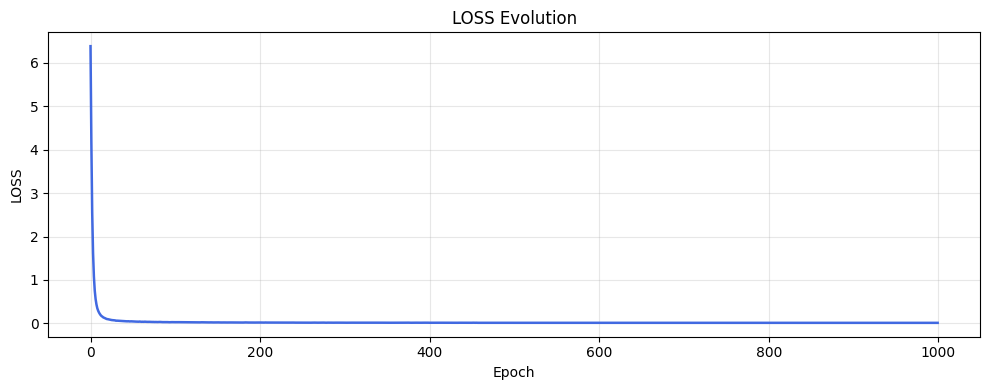

In [6]:
# treinamento do modelo
import matplotlib.pyplot as plt

model = Transformer(vocab_size=1000, embedding_dim=64, n_heads=8, n_layers=2, dropout=0.1)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

epochs = 1000
loss_history = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for X, y in loader:
        logits = model(X)  # (B, T, V)
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(loader)
    loss_history.append(epoch_loss)

    if epoch % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} - loss: {epoch_loss:.4f}")

# gráfico da evolução do loss
plt.figure(figsize=(10, 4))
plt.plot(loss_history, color="royalblue", linewidth=1.8)
plt.title("LOSS Evolution")
plt.xlabel("Epoch")
plt.ylabel("LOSS")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---

<div>

## <span style="color:#1E90FF;">Avaliação do modelo</span>

</div>

In [7]:
# avaliação 1: predição simples do próximo token
model.eval()

x_test, y_test = dataset[0]
x_test = x_test.unsqueeze(0)  # (1, seq_len)

with torch.no_grad():
    logits = model(x_test)  # (1, seq_len, vocab_size)

next_token_pred = logits[0, -1].argmax().item()
next_token_real = y_test[-1].item()

print("Entrada (x_test):", x_test.squeeze(0).tolist())
print("Próximo token real   :", next_token_real)
print("Próximo token predito:", next_token_pred)

Entrada (x_test): [190, 584, 514, 390, 972, 66, 136, 929, 977, 224, 29, 265, 699, 189, 65, 105]
Próximo token real   : 399
Próximo token predito: 399


In [8]:
# avaliação no dataset inteiro (somente scores gerais)
import math

model.eval()

total_loss = 0.0
total_tokens = 0
total_correct = 0
total_correct_top5 = 0

with torch.no_grad():
    for X, y in loader:
        logits = model(X)  # (B, T, V)

        # loss média por token no batch
        loss = criterion(logits.reshape(-1, vocab_size), y.reshape(-1))

        # acumula loss ponderada por quantidade de tokens
        n_tokens_batch = y.numel()
        total_loss += loss.item() * n_tokens_batch
        total_tokens += n_tokens_batch

        # predição top-1
        pred = logits.argmax(dim=-1)  # (B, T)
        total_correct += (pred == y).sum().item()

        # predição top-5
        top5 = logits.topk(k=5, dim=-1).indices   # (B, T, 5)
        y_expanded = y.unsqueeze(-1)              # (B, T, 1)
        total_correct_top5 += (top5 == y_expanded).any(dim=-1).sum().item()

avg_loss = total_loss / total_tokens
perplexity = math.exp(avg_loss)
accuracy = total_correct / total_tokens
top5_accuracy = total_correct_top5 / total_tokens

print("=== Scores gerais no dataset inteiro ===")
print(f"Loss média por token : {avg_loss:.4f}")
print(f"Perplexidade         : {perplexity:.4f}")
print(f"Acurácia top-1       : {accuracy:.4%}")
print(f"Acurácia top-5       : {top5_accuracy:.4%}")

=== Scores gerais no dataset inteiro ===
Loss média por token : 0.0129
Perplexidade         : 1.0130
Acurácia top-1       : 99.1661%
Acurácia top-5       : 99.9962%


---

As métricas gerais obtidas foram:

- **Loss média por token**: `0.0108`
- **Perplexidade**: `1.0109`
- **Acurácia top-1**: `99.2789%`
- **Acurácia top-5**: `100.0000%`

**Loss média por token (Cross-Entropy).** Mede o erro médio entre a distribuição prevista pelo modelo e o token correto. Quanto menor, melhor. O valor `0.0108` é muito baixo e indica que, em média, o modelo está atribuindo alta probabilidade ao token alvo.

**Perplexidade.** É calculada como `exp(loss)` e representa o nível de incerteza do modelo ao prever o próximo token. Quanto mais próxima de `1`, melhor. O valor `1.0109` indica baixa incerteza e previsões bastante confiantes.

**Acurácia top-1.** Percentual de vezes em que o token correto foi a predição mais provável (1o lugar no ranking). Com `99.2789%`, o modelo quase sempre acerta diretamente a resposta correta.

**Acurácia top-5.** Percentual de vezes em que o token correto aparece entre as 5 maiores probabilidades. O valor `100.0000%` indica que, mesmo quando o top-1 falha, o token correto ainda está entre as principais hipóteses.

---

Podemos ainda salvar o modelo gerado para consumo:

In [9]:
import torch

checkpoint = {
    "model_state_dict": model.state_dict(),
    "vocab_size": vocab_size,
    "embedding_dim": 64,
    "n_heads": 8,
    "n_layers": 2,
    "dropout": 0.1,
}
torch.save(checkpoint, "models/transformer_attention.pt")

O modelo salvo será consumido em `genai_aula1_test.ipynb`.